In [65]:
import h5py
from scipy import signal
from scipy.signal import welch, csd
import matplotlib.pyplot as plt
from os import listdir
import numpy as np
from scipy import fft
from scipy.stats import norm
import pickle
from datetime import datetime

In [66]:
folder = r'C:\Users\21958742\MAGE\MAGE3\Analysis\run2-Teff/'

In [67]:
with open(folder + 'event_catalogue-strain-Teff.pkl', 'rb') as f:
    event_catalogue = pickle.load(f)
    
with open(folder + 'co_event_strain-Teff.pkl', 'rb') as f:
    co_events = pickle.load(f)

## Preamble

In [68]:
SNRs1 = np.array([(event_catalogue[event]['SNR'],event_catalogue[event]['Teff']) for event in event_catalogue if event_catalogue[event]['input AI'] == 1])
SNRs0 =  np.array([(event_catalogue[event]['SNR'],event_catalogue[event]['Teff']) for event in event_catalogue if event_catalogue[event]['input AI'] == 0])
frequencies = [event_catalogue[event]['frequency'] for event in event_catalogue]

AI0_ch1_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 1) & (event_catalogue[event]['input AI']==0)]
AI0_ch2_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 2) & (event_catalogue[event]['input AI']==0)]
AI0_ch3_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 3) & (event_catalogue[event]['input AI']==0)]
AI0_ch4_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 4) & (event_catalogue[event]['input AI']==0)]
AI0_ch5_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 5) & (event_catalogue[event]['input AI']==0)]
AI0_ch6_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 6) & (event_catalogue[event]['input AI']==0)]
AI0_ch7_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 7) & (event_catalogue[event]['input AI']==0)]
AI0_ch8_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 8) & (event_catalogue[event]['input AI']==0)]
AI0_ch9_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 9) & (event_catalogue[event]['input AI']==0)]
AI0_ch10_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 10) & (event_catalogue[event]['input AI']==0)]
AI0_ch11_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 11) & (event_catalogue[event]['input AI']==0)]
AI0_ch12_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 12) & (event_catalogue[event]['input AI']==0)]
AI0_ch13_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 13) & (event_catalogue[event]['input AI']==0)]
AI0_ch14_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 14) & (event_catalogue[event]['input AI']==0)]
AI0_ch15_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 15) & (event_catalogue[event]['input AI']==0)]
AI0_ch16_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 16) & (event_catalogue[event]['input AI']==0)]

AI1_ch1_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 1) & (event_catalogue[event]['input AI']==1)]
AI1_ch2_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 2) & (event_catalogue[event]['input AI']==1)]
AI1_ch3_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 3) & (event_catalogue[event]['input AI']==1)]
AI1_ch4_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 4) & (event_catalogue[event]['input AI']==1)]
AI1_ch5_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 5) & (event_catalogue[event]['input AI']==1)]
AI1_ch6_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 6) & (event_catalogue[event]['input AI']==1)]
AI1_ch7_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 7) & (event_catalogue[event]['input AI']==1)]
AI1_ch8_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 8) & (event_catalogue[event]['input AI']==1)]
AI1_ch9_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 9) & (event_catalogue[event]['input AI']==1)]
AI1_ch10_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 10) & (event_catalogue[event]['input AI']==1)]
AI1_ch11_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 11) & (event_catalogue[event]['input AI']==1)]
AI1_ch12_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 12) & (event_catalogue[event]['input AI']==1)]
AI1_ch13_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 13) & (event_catalogue[event]['input AI']==1)]
AI1_ch14_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 14) & (event_catalogue[event]['input AI']==1)]
AI1_ch15_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 15) & (event_catalogue[event]['input AI']==1)]
AI1_ch16_events = [(event_catalogue[event]['SNR'], event_catalogue[event]['Teff']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 16) & (event_catalogue[event]['input AI']==1)]


In [69]:
np.array([(np.array(SNRs0))[:,0].max(),(np.array(SNRs1))[:,0].min()]).max()


5.425719805301838

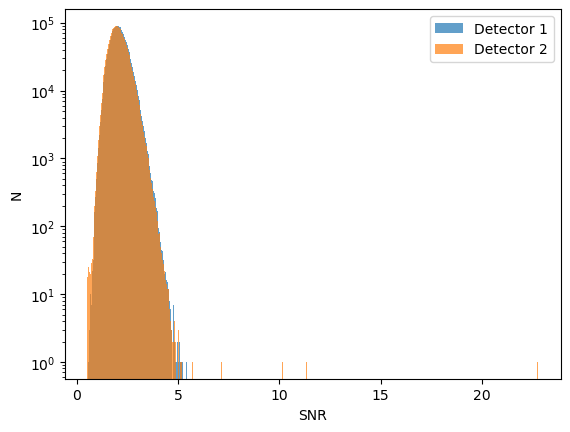

In [70]:
xmin = np.array([(np.array(SNRs0))[:,0].min(),(np.array(SNRs1))[:,0].min()]).min()
xmax = np.array([(np.array(SNRs0))[:,0].max(),(np.array(SNRs1))[:,0].max()]).max()

plt.hist((np.array(SNRs0))[:,0], alpha = 0.7, label = 'Detector 1', bins = 500, range = (xmin, xmax))
plt.hist((np.array(SNRs1))[:,0], alpha = 0.7, label = 'Detector 2', bins = 500, range = (xmin, xmax))
plt.yscale('log')
plt.xlabel('SNR')
plt.ylabel('N')
plt.legend(loc=0)
plt.show()

In [71]:
normalised_cut_0 = [event for event in np.array(SNRs0)[:,0] if event>0]
normalised_cut_1 = [event for event in np.array(SNRs1)[:,0] if event>0]

In [72]:
Nbins = 10000
ii=50
jj=200

Tn_height, Tn_edge = np.histogram((np.array(SNRs0)**2)[:,0], bins = Nbins, range=(1,600))
Tn_wk_height, Tn_wk_edge = np.histogram((np.array(SNRs1)**2)[:,0], bins = Nbins, range=(1,600))


Tfit_m, Tfit_b = np.polyfit(Tn_edge[ii:jj],np.log(Tn_height[ii:jj]+1),1)
Tfit_wk_m, Tfit_wk_b = np.polyfit(Tn_wk_edge[ii:jj],np.log(Tn_wk_height[ii:jj]+1),1)

tn_T = np.linspace(0.0,max(Tn_edge)*0.99,Nbins)

In [73]:
excess_events = [excess_index for excess_index in range(len(Tn_wk_height)) if Tn_wk_height[excess_index] > 2*np.exp(Tfit_wk_m*Tn_wk_edge[excess_index]+Tfit_wk_b)]

excess_heights = [Tn_wk_height[i] for i in excess_events]
excess_edges = [Tn_wk_edge[i] for i in excess_events]

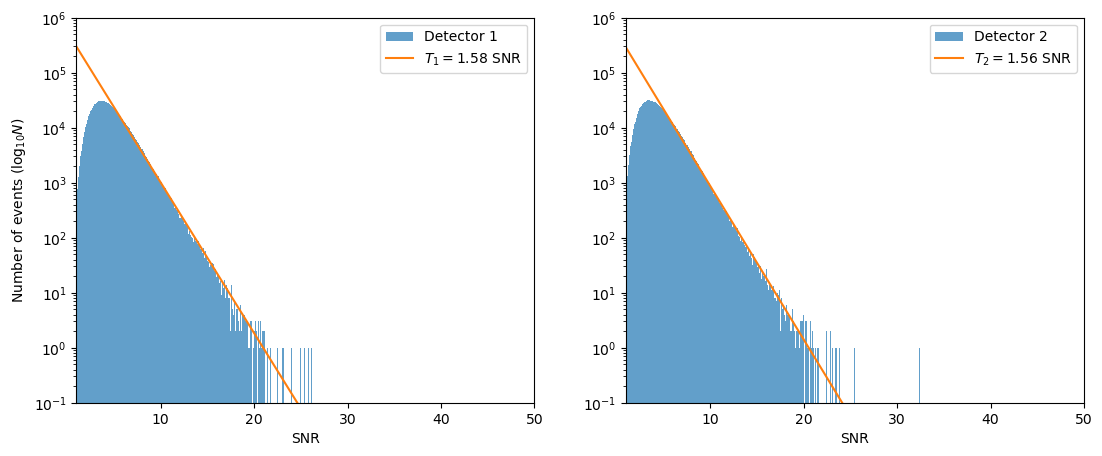

In [74]:
fig,ax = plt.subplots(1,2, figsize=(13,5))
ax[0].hist((np.array(SNRs0)**2)[:,0],bins=Nbins, linewidth=0, alpha = 0.7, label='Detector 1',range=(1,600))
ax[1].hist((np.array(SNRs1)**2)[:,0],bins=Nbins,linewidth=0, alpha = 0.7, label = 'Detector 2',range=(1,600))

ax[0].plot(tn_T,np.exp(Tfit_m*tn_T+Tfit_b), label = r'$T_1=$%1.2f' % (-1/Tfit_m) + ' SNR')
ax[1].plot(tn_T,np.exp(Tfit_wk_m*tn_T+Tfit_wk_b), label = r'$T_2=$%1.2f' % (-1/Tfit_wk_m) + ' SNR')
#ax.plot(excess_edges, excess_heights, linestyle = ' ', marker = 'x')
ax[0].legend(loc=0)
ax[1].legend(loc=0)
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].set_ylim(0.1,1e6)
ax[0].set_xlim(1,50)
ax[1].set_ylim(0.1,1e6)
ax[1].set_xlim(1,50)
ax[0].set_xlabel(r'SNR')
ax[1].set_xlabel('SNR')
ax[0].set_ylabel(r'Number of events ($\mathrm{log}_{10}N$)')
pp = folder + 'hist.pdf'
plt.savefig(pp, format='pdf', dpi=600)

In [75]:
x = np.array(AI1_ch1_events)[:,0]
x = np.array([np.abs(event_catalogue[event]['amplitude']) for event in event_catalogue if 
                  (event_catalogue[event]['channel'] == 1) & (event_catalogue[event]['input AI']==0)])
Temp = ((np.fft.ifft(np.fft.fft(np.abs(x))*(2*np.pi*4993050.0))).real)**2*4.668424716530595e+17

<function matplotlib.pyplot.show(close=None, block=None)>

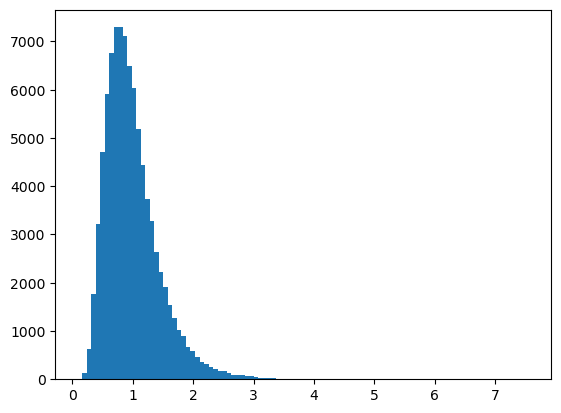

In [76]:
plt.hist(Temp, bins = 100)
plt.show

In [77]:
large_events = [event for event in event_catalogue if 4<event_catalogue[event]['SNR']<5 and event_catalogue[event]['file N'] != 469]
xlarge_events = [event for event in event_catalogue if 5<event_catalogue[event]['SNR']<1000 and event_catalogue[event]['file N'] != 469]

In [78]:
# event_catalogue[xlarge_events[0]]

In [79]:
times1 =  [event_catalogue[event]['time'].timestamp() for event in event_catalogue if (event_catalogue[event]['input AI'] == 1 and event_catalogue[event]['SNR'] > 1.0)]
times0 =  [event_catalogue[event]['time'].timestamp() for event in event_catalogue if (event_catalogue[event]['input AI'] == 0 and event_catalogue[event]['SNR'] > 1.0)]

In [80]:
# coincident_0 = []
# for time0 in times0:
#     for time1 in times1:
#         if np.abs(time0-time1) < 0.01:
#             #print("Coincident Event at " + str(time0))
#             coincident_0.append(time0)

In [81]:
# coincident_1=[]
# for time0 in times0:
#     for time1 in times1:
#         if np.abs(time0-time1) < 0.01:
#             #print("Coincident Event at " + str(time1))
#             coincident_1.append(time1)

In [82]:
# candidate_event = []

# for ii in range(len(coincident_0)):
#     co_event_nn = ii
#     co_event = [(event, event_catalogue[event]) for event in event_catalogue if event_catalogue[event]['time'] == datetime.fromtimestamp(coincident_0[co_event_nn])], [(event, event_catalogue[event]) for event in event_catalogue if event_catalogue[event]['time'] == datetime.fromtimestamp(coincident_1[co_event_nn])]
#     if (co_event[0][0][1]['channel'] == co_event[1][0][1]['channel']):
#         candidate_event.append(co_event)
# print(len(candidate_event))

In [83]:
# Rt = 2.5
# [event for event in co_events if ((event[1][1]['SNR'])>Rt)]

In [84]:
feffective_mass = open(r'C:\Users\21958742\MAGE\MAGE3/' + 'calibration/Meff.txt')
mode_distributions = np.genfromtxt(feffective_mass, delimiter=',', skip_header=1)
meff = mode_distributions[:,1]
xi = mode_distributions[:,2]

Q0 = [18058011.18, 1254696.59, 3494654.17,16962105.92, 5689899.46, 60565757.57, 33267926.78, 44653062.80, 30585969.48, 26510994.90
    , 37422944.61, 76843447.08, 93176978.34, 65648054.33, 115047095.19, 75204332.18]
Q1 = [48270564.00,630770.50,6453914.00,56212596.00,6115535.00,66870760.00,79754832.00,44126040.00,63588400.00,18052478.00,52137668.00,29066436.00,119769688.00,99094616.00,163072160.00,23392774.00]

In [85]:
Texcl = np.zeros(16)
hcexcl = np.zeros(16)
fvec = np.zeros(16)
Dexcl = np.zeros(16)
for i in range(16):
    channel=i
    Rt0 = np.max([event[0][1]['SNR'] for event in co_events if (event[0][1]['channel']==channel+1)])
    Rt1 = np.max([event[1][1]['SNR'] for event in co_events if (event[0][1]['channel']==channel+1)])

    Rtcombined = np.max([(event[0][1]['SNR']+event[1][1]['SNR']) for event in co_events if (event[0][1]['channel']==channel+1)])
    target_event0 = [event for event in co_events if event[0][1]['SNR'] == Rt0]
    target_event1 = [event for event in co_events if event[1][1]['SNR'] == Rt1]

    deth0 = target_event0[0][0][1]['amplitude']
    deth1 = target_event1[0][1][1]['amplitude']

    norm0 = 3.5/target_event0[0][0][1]['Teff']
    norm1 = 3.5/target_event0[0][1][1]['Teff']

    f_demod = target_event0[0][0][1]['frequency']

    normed_deth0, normed_deth1 = np.sqrt(norm0)*np.abs(deth0),  np.sqrt(norm1)*np.abs(deth1)

    T0,T1 = 0.5*np.abs(normed_deth0)**2*(f_demod*2*np.pi)**2*meff[channel]/(1.380649e-23), 0.5*np.abs(normed_deth1)**2*(f_demod*2*np.pi)**2*meff[channel]/(1.380649e-23)
    Texcl[i] = np.array([T0,T1]).max()
    fvec[i] = f_demod
    
    hcdet0 = np.abs(deth0)*np.sqrt(f_demod**2/2)/(0.5*1.093e-3*xi[channel]*Q0[channel])
    hcdet1 = np.abs(deth1)*np.sqrt(f_demod**2/2)/(0.5*1.093e-3*xi[channel]*Q1[channel])
    Mpbh = 4.3758e33/f_demod
    Msolar = 1.989e30
    MM = (Mpbh**2)**(3/5)/(2**(1/5)*Mpbh**(1/5))
    Ncycles = 5.42532e56/(f_demod**(3/2)*MM**(5/3))
    hc0, hc1 = hcdet0/np.sqrt(2*Ncycles), hcdet1/np.sqrt(2*Ncycles)
    hcexcl[i] = np.array([hc0,hc1]).max()
    D = 5.83209e-51*f_demod**(2/3)*MM**(5/3)/np.array([hc0,hc1]).max()
    Dexcl[i] = D

In [86]:
Ncycles

92.43028333633406

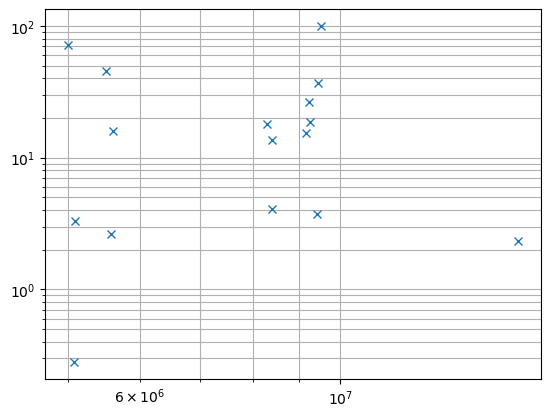

In [87]:
plt.plot(fvec, Dexcl/1.496E+11, linestyle = ' ', marker='x')
plt.xscale('log')
plt.yscale('log')
plt.grid(which='both')

In [88]:
x = [event[0][1]['SNR'] for event in co_events]
y = [event[1][1]['SNR'] for event in co_events]

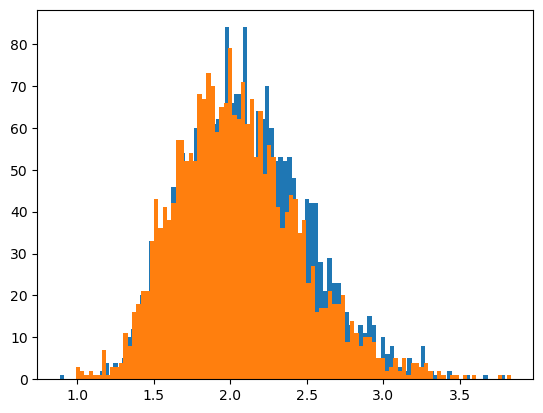

In [89]:
plt.hist(x, bins = 100)
plt.hist(y, bins = 100)
plt.show()

In [90]:
import h5py
from scipy import signal
from scipy.signal import welch, csd
import matplotlib
import matplotlib.pyplot as plt
import os
from os import listdir
import numpy as np
from scipy import fft
from scipy.signal import find_peaks
import lmfit
from datetime import datetime
from datetime import timedelta
#file by file data analysise

## Transient filter search for MAGE data stream. First test designed for MAGE0 Data

#load data file
folder = r"C:\Users\21958742\MAGE/"
exp_name = "MAGE3"
run_name = "run2"
identifier = 'run2-'

files = listdir(folder + '/' + exp_name + '/' + run_name)
Nfiles = len(files)

#meta data from first file
f = h5py.File(folder + '/' + exp_name + '/' + run_name + '/' + files[0], 'r')
f1 = h5py.File(folder + '/' + exp_name + '/' + run_name + '/' + files[1], 'r')

#load calibration data
fsquid = open(folder + '/' + exp_name + '/calibration/SQUID gain models.txt')
fresistance = open(folder + '/' + exp_name + '/calibration/Rs.txt')
feffective_mass = open(folder + '/' + exp_name + '/calibration/Meff.txt')
squid_model = np.genfromtxt(fsquid, skip_header=1, delimiter=',')
resistances = np.genfromtxt(fresistance, delimiter=',')
mode_distributions = np.genfromtxt(feffective_mass, delimiter=',', skip_header=1)
meff = mode_distributions[:,1]
xi = mode_distributions[:,2]

Ninputs = len(f.keys())
Nchannels = len(f['AI 0'].keys())//2
Nsample = len(f1['AI 0/CH 1-I/Data'][:])
Fs = f['AI 0'].attrs['Fs']
dt = 1/Fs
data_array = np.zeros((Ninputs, Nchannels, 2, Nsample))
t_start_string = str(f['AI 0'].attrs['date/time string'])
t_start = datetime.strptime(t_start_string, 'UTC %d-%m-%y %H:%M:%S.%f ')

kb = 1.380649e-23
event_catalogue={}
#create output folder to store analysis results
output_path = folder + '/' + exp_name + '/Analysis/' + run_name + '-1 sigma'
if os.path.exists(output_path) == False:
    os.makedirs(output_path)

#filter function
def optimal_filter(data, template, Fs, NFFT):
    fft = np.fft.fft(data) # fourier transformed data
    zero_pad = np.zeros(data.size - template.size) # zero pad template to match data size
    template_pad = np.append(template, zero_pad)
    fft_template = np.fft.fft(template_pad) # fourier transformed padded template
    power_dat, freq_PSD = plt.psd(data, Fs=Fs, NFFT = NFFT, visible = True)
    freq_dat = np.fft.fftfreq(data.size)*Fs #fourier frequencies corresponding to data partition
    power_spec = np.interp(freq_dat, freq_PSD, power_dat)
    
    val_cal = np.max(template)
    OF = np.fft.ifft(fft_template*fft_template.conjugate()/power_spec).real
    K = val_cal/np.amax(OF)
    
    
    df = np.abs(freq_dat[1] - freq_dat[2])
    opt_filter = K * fft * fft_template.conjugate() / power_spec #optimal filter
    dat_filt = np.fft.ifft(opt_filter) #revert to time domain for filter output
    
    sigmasq = 2*(K**2 * fft_template * fft_template.conjugate() / power_spec).sum() * df 
    sigma = np.sqrt(np.abs(sigmasq))
    SNR = np.abs(2*dat_filt) / (sigma)
    return SNR, dat_filt
def fit_spectrum(Sx_trim,Sy_trim,fn_trim, plotting=True, return_peak = False):
    
    pars = peak_model.guess(Sx_trim, x=fn_trim)
    pars += noise_model.guess(Sx_trim, x=fn_trim)
    pars2 = peak_model.guess(Sx_trim, x=fn_trim)
    pars2 += noise_model.guess(Sx_trim, x=fn_trim)
    model = peak_model + noise_model

    out = model.fit(Sx_trim, pars, x=fn_trim)
    out2 = model.fit(Sy_trim, pars2, x=fn_trim)
    Gamma1, Gamma2 = out.params["sigma"].value, out2.params["sigma"].value
    fcenter1, fcenter2 = out.params["center"].value, out2.params["center"].value
    h1, h2 = out.params["height"].value + out.params["c"].value, out2.params["height"].value + out2.params["c"].value
    f_demod = f['AI ' + str(AI)].attrs['Demod freqs AI ' + str(AI)][channel] # demodulation frequency

    Q1, Q2 = (fcenter1+f_demod)/(2*Gamma1), (fcenter2+f_demod)/(2*Gamma2)
    if out.params["sigma"].stderr == None:
        error1 = 0.99
    else:
        error1 =  out.params["sigma"].stderr/out.params["sigma"].value
    if out2.params["sigma"].stderr == None:
        error2 = 0.99
    else:
        error2 =  out2.params["sigma"].stderr/out2.params["sigma"].value
    #if Gamma1 > Gamma_max or Gamma2 > Gamma_max or error1 > error_max or error2 > error_max: #Ignore bad fits
        #print("Input AI " + str(AI) + ", Channel " + str(channel+1) + ":WARNING: Bad mode detected, channel will be ignored")
    if plotting==True:
        fig = plt.figure("IMPA DOWNLOAD")
        plt.axis('tight')
        ax = fig.add_subplot(111)
        ax.plot(fn_trim, Sx_trim, 'o', markersize=0.2)
        ax.set_title("Input AI " + str(AI) + ", Channel " + str(channel+1))
        #plt.plot(fn_n, out.init_fit, '--', label='initial fit')
        ax.plot(fn_trim, out.best_fit, '-', label='best fit I')
        ax.plot(fn_trim, out2.best_fit, '-', label='best fit Q')
        ax.set_yscale('log')
        #ax.set_xscale('log')
        ax.legend()
    if return_peak:
        return Q1,Q2,Gamma1,Gamma2,fcenter1,fcenter2, h1, h2
    else:
        return Q1,Q2,Gamma1,Gamma2,fcenter1,fcenter2

## Analysis Summary

Summary of ~ 15 days of data collected for the MAGE 3 run, in which 16 modes where continously monitored across two crystals.

Taking a look at an example file of some sampled data

In [91]:
file = 56
channel = 0
AI = 1

from lmfit.models import LorentzianModel, LinearModel

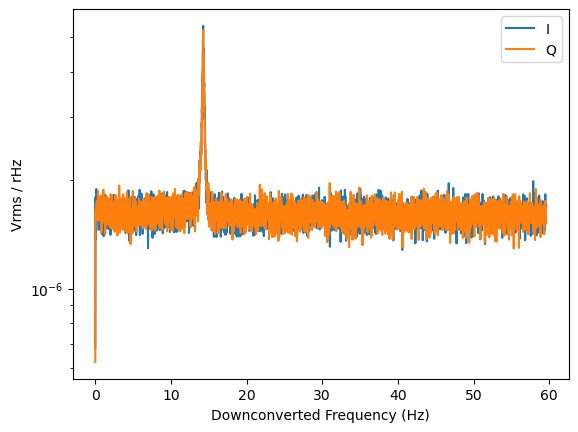

In [92]:
f = h5py.File(folder + '/' + exp_name + '/' + run_name + '/' + identifier + str(file) + '.hdf5', 'r')
dataI = f['AI ' + str(AI) + '/CH ' + str(channel+1) + '-I/Data'][:]*9.86e-10
dataQ = f['AI ' + str(AI) + '/CH ' + str(channel+1) + '-Q/Data'][:]*9.86e-10
Rdat = np.sqrt(dataI**2+dataQ**2)
#Determine single sided power spectrum for each stream
NFFT = 2**12 # for NFFT < Nsample power spectrum will be averaged

fn, SdataI = welch(dataI, fs=Fs, nperseg = 2*NFFT-1, scaling = 'density')
fn, SdataQ = welch(dataQ, fs=Fs, nperseg = 2*NFFT-1, scaling = 'density')
plt.plot(fn,np.sqrt(SdataI),label='I')
plt.plot(fn,np.sqrt(SdataQ),label='Q')
#plt.xscale('log')
plt.yscale('log')
plt.ylabel('Vrms / rHz')
plt.xlabel('Downconverted Frequency (Hz)')
plt.legend()

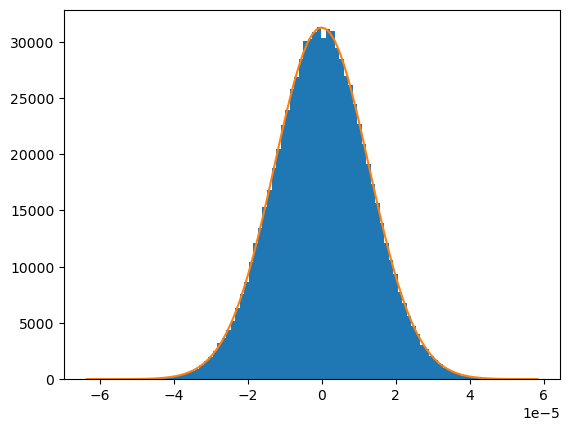

In [93]:
x = dataI

mu, sigma = norm.fit(x)
n, bins, patches = plt.hist(x, bins=100, density=True)
plt.plot(bins, norm.pdf(bins, mu, sigma))
plt.show()

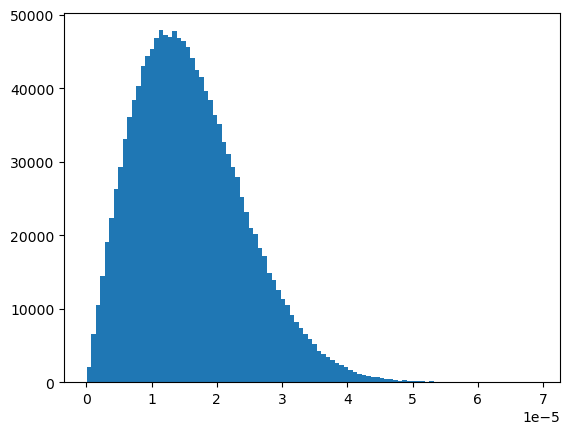

In [94]:
n, bins, patches = plt.hist(Rdat, bins=100, density=True)
plt.show()

The magnitude data $R$ is converted into detector displacement by $u_\mathrm{rms} = \int \frac{I}{\kappa_\lambda} dt = \frac{R}{G_\mathrm{SQUID}\omega_\lambda}$

The displacement time series is then searched for signals of shape $e^{-t/\tau_\lambda}$ via the optimal filter

Below is an example of constructing the optimal filter, and then applying it to the data. First the PSD is fit to extract critical parameters such as Q and $\tau_\lambda$

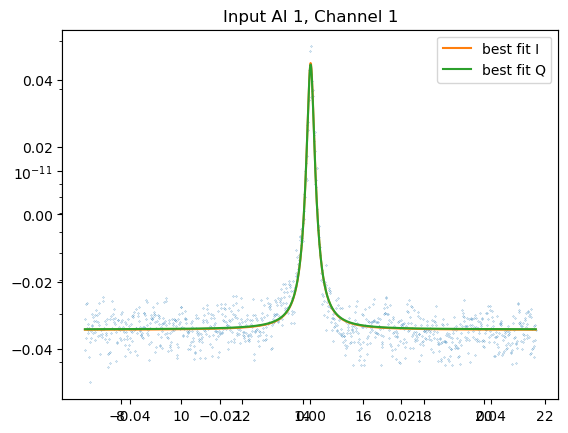

In [95]:
from lmfit.models import ConstantModel
peak_model = LorentzianModel()
noise_model = ConstantModel()

peak_ii = np.where(SdataI==np.max(SdataI))[0][0]
ii_span = 2**10

ss = peak_ii-ii_span//2
tt = peak_ii+ii_span//2
if ss < 1:
    ss = 0

Sx_trim = SdataI[ss:tt]
Sy_trim = SdataQ[ss:tt]
fn_trim = fn[ss:tt]

Q1,Q2,Gamma1,Gamma2,fc1,fc2, h1, h2 = fit_spectrum(Sx_trim, Sy_trim, fn_trim, return_peak=True)

The optimal filter function is then constructed as $\frac{K\tilde{u}(\omega)\tilde{h}(\omega)}{S_u(\omega)}$

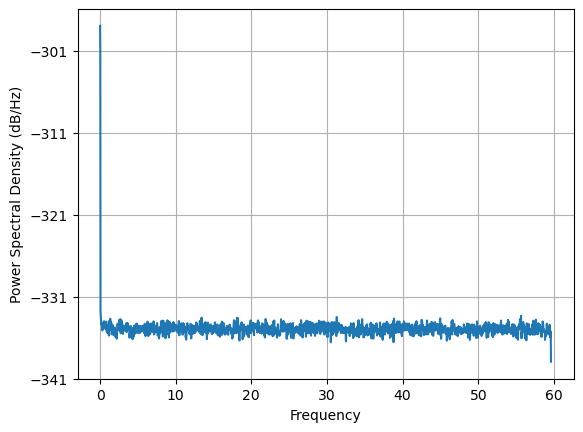

In [96]:
f_demod = f['AI ' + str(AI)].attrs['Demod freqs AI ' + str(AI)][channel] # demodulation frequency
tau1, tau2 = np.array([Q1,Q2])/(np.pi*f_demod)
fpeak_sig = fc1

Nfilter=int(Fs*5*tau1)
tn = np.linspace(0,Nsample*dt,Nsample)
t_sig = dt*np.linspace(0, Nfilter, Nfilter)

G = squid_model[AI][0]/np.sqrt(1+(f_demod/squid_model[AI][1])**2) #squid gain
VtoT = (1/G)**2*resistances[channel][AI]*tau1/kb/4

kappa = np.sqrt(f_demod*2*np.pi*meff[channel]/(Q1*resistances[channel][AI]))
template = np.exp(-t_sig/(tau1)) # template construction

h = np.fft.ifft(np.fft.fft(Rdat[1:]/G)/(kappa*f_demod*2*np.pi)).real
SNR, dat_filt = optimal_filter(h, template, Fs, NFFT)

C:\Users\21958742\AppData\Local\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


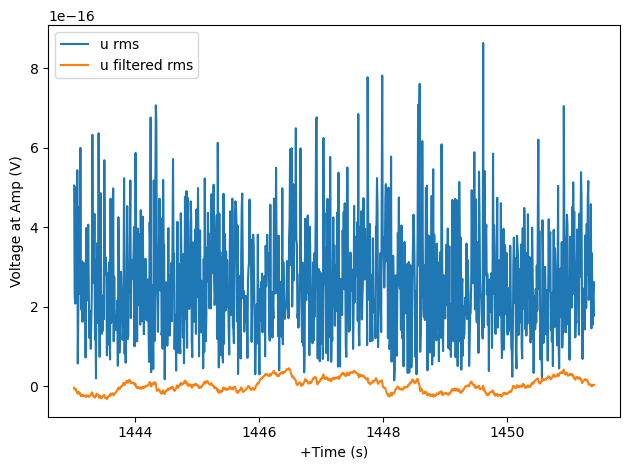

In [97]:
date = f['AI 0'].attrs['date/time string'][:]

nn = 172521
span = 500

plt.plot(tn[nn-span:nn+span], h[nn-span:nn+span], label = 'u rms')
plt.plot(tn[nn-span:nn+span], dat_filt[nn-span:nn+span], label = 'u filtered rms')
plt.legend(loc=0)
plt.xlabel('+Time (s)')
plt.ylabel('Voltage at Amp (V)')
plt.tight_layout()

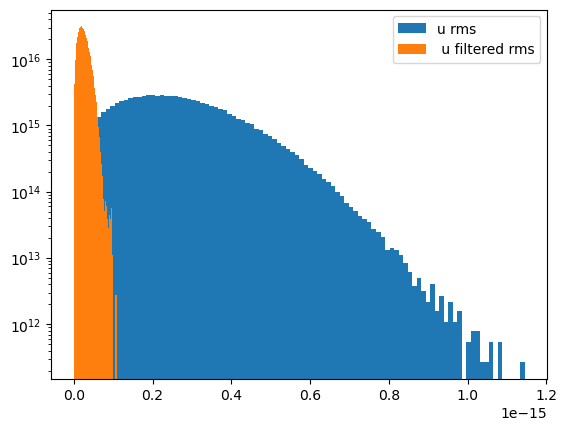

In [98]:
plt.hist(h, bins=100, label= 'u rms', density=True)
plt.hist(np.abs(dat_filt), bins=100, label = ' u filtered rms', density=True)
plt.yscale('log')
plt.legend()

Optimal filter correctly returns data centered about a mean energy SNR of 1

In [99]:
np.mean(SNR**2)

0.9999057861688208

After filtering all peaks in the SNR spectrum above threshold SNR=1 are found

A template bank is then created with 3 templates by varing the exponential decay time $\tau_1 = \tau_\lambda/10,~\tau_2=\tau_\lambda,~\tau_3=10\tau_\lambda$

We thus only keep SNR peaks where $\tau_2$ is maximised

We can inject a signal via simulation to show what this process should look liked

In [100]:
signal = 1e-16*np.exp(-t_sig/(tau1))
template = np.exp(-t_sig/(tau1))
zero_pad = np.zeros(h.size - signal.size) # zero pad template to match data size
template_pad = np.roll(np.append(signal, zero_pad),50000)

h_inject = template_pad + np.abs(np.random.normal(0, 1.66*np.std(h), size = len(h)))
h_inject2 = np.abs(np.random.normal(0, 1.66*np.std(h), size = len(h)))

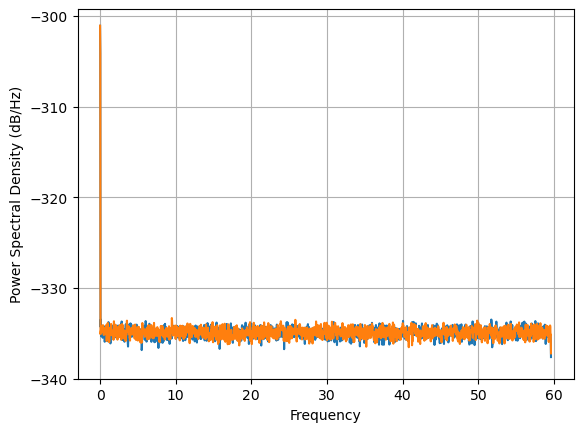

In [101]:
SNR, dat_filt = optimal_filter(h_inject, template, Fs, NFFT)
SNR2, dat_filt2 = optimal_filter(h_inject2, template, Fs, NFFT)

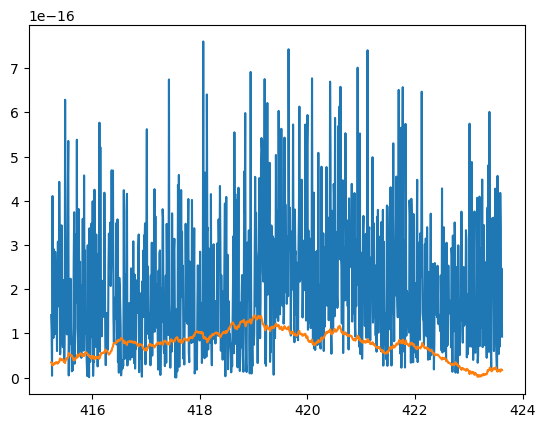

In [102]:
nn = 50000
span = 1000
plt.plot(tn[nn-span//2:nn+span//2], h_inject[nn-span//2:nn+span//2])
plt.plot(tn[nn-span//2:nn+span//2], abs(dat_filt)[nn-span//2:nn+span//2])

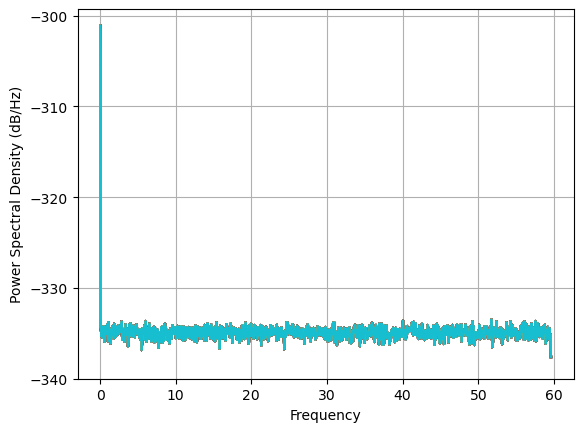

In [103]:
Ntemplates = 100
Span = 500
SNR_arr = np.zeros((Ntemplates, Span))
tau_vec = tau1*np.logspace(-1,1,Ntemplates)
for i in range(Ntemplates):
    template = np.exp(-t_sig/(tau_vec[i]))
    SNR, dat_filt = optimal_filter(h_inject, template, Fs, NFFT)
    SNR_arr[i,:] = SNR[nn-Span//2:nn+Span//2]

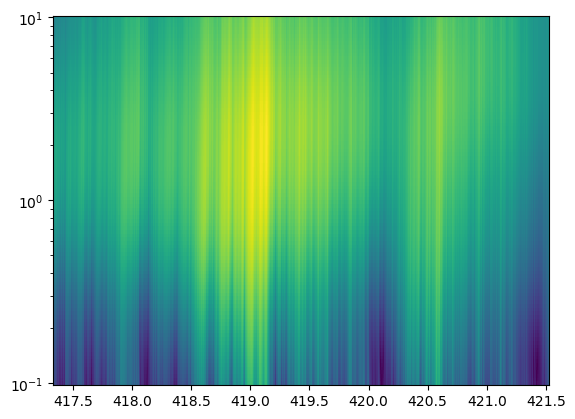

In [104]:
XX, YY = np.meshgrid(tn[nn-Span//2:nn+Span//2], tau_vec/tau1)
ZZ = SNR_arr[:,:]
fig, ax = plt.subplots(1)
ax.pcolormesh(XX,YY, ZZ, cmap='viridis')
ax.set_yscale('log')

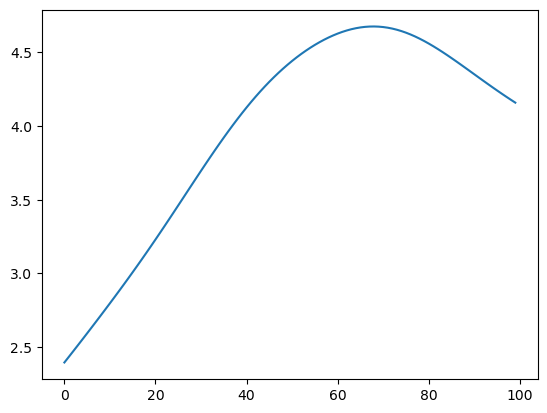

In [105]:
plt.plot(SNR_arr[:,Span//2])

We can compare this to a large muon event found in the real data

In [106]:
channel=2

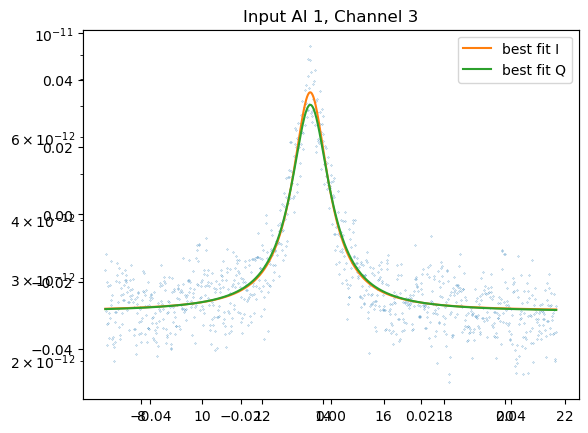

In [107]:
dataI = f['AI ' + str(AI) + '/CH ' + str(channel+1) + '-I/Data'][:]*9.86e-10
dataQ = f['AI ' + str(AI) + '/CH ' + str(channel+1) + '-Q/Data'][:]*9.86e-10
Rdat = np.sqrt(dataI**2+dataQ**2)

fn, SdataI = welch(dataI, fs=Fs, nperseg = 2*NFFT-1, scaling = 'density')
fn, SdataQ = welch(dataQ, fs=Fs, nperseg = 2*NFFT-1, scaling = 'density')

ss = peak_ii-ii_span//2
tt = peak_ii+ii_span//2
if ss < 1:
    ss = 0

Sx_trim = SdataI[ss:tt]
Sy_trim = SdataQ[ss:tt]
fn_trim = fn[ss:tt]

Q1,Q2,Gamma1,Gamma2,fc1,fc2, h1, h2 = fit_spectrum(Sx_trim, Sy_trim, fn_trim, return_peak=True)

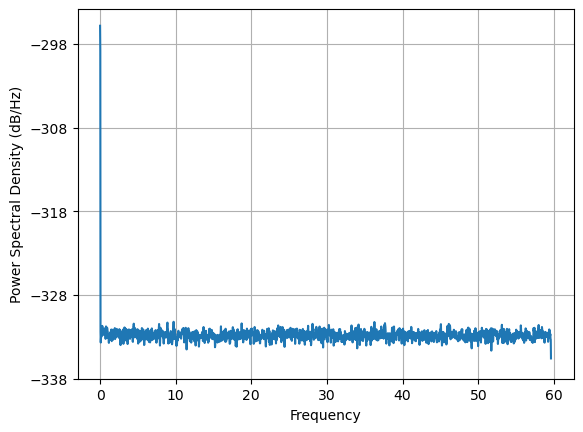

In [108]:
f_demod = f['AI ' + str(AI)].attrs['Demod freqs AI ' + str(AI)][channel] # demodulation frequency
tau1, tau2 = np.array([Q1,Q2])/(np.pi*f_demod)
fpeak_sig = fc1

Nfilter=int(Fs*5*tau1)
tn = np.linspace(0,Nsample*dt,Nsample)
t_sig = dt*np.linspace(0, Nfilter, Nfilter)

G = squid_model[AI][0]/np.sqrt(1+(f_demod/squid_model[AI][1])**2) #squid gain
VtoT = (1/G)**2*resistances[channel][AI]*tau1/kb/4

kappa = np.sqrt(f_demod*2*np.pi*meff[channel]/(Q1*resistances[channel][AI]))
template = np.exp(-t_sig/(tau1)) # template construction

h = np.fft.ifft(np.fft.fft(Rdat[1:]/G)/(kappa*f_demod*2*np.pi)).real
SNR, dat_filt = optimal_filter(h, template, Fs, NFFT)

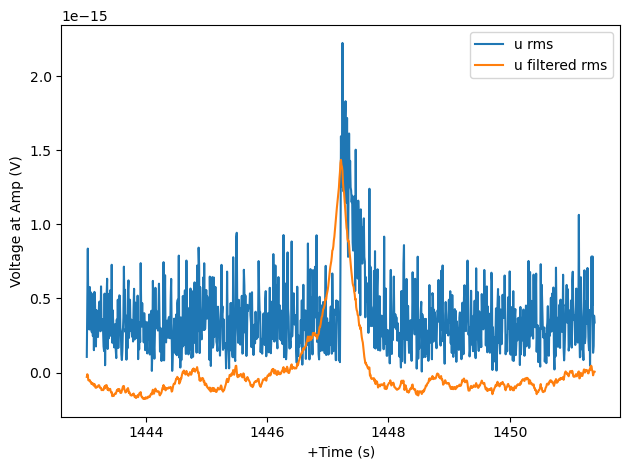

In [109]:
date = f['AI 0'].attrs['date/time string'][:]

nn = 172521
span = 500

plt.plot(tn[nn-span:nn+span], h[nn-span:nn+span], label = 'u rms')
plt.plot(tn[nn-span:nn+span], dat_filt[nn-span:nn+span], label = 'u filtered rms')
plt.legend(loc=0)
plt.xlabel('+Time (s)')
plt.ylabel('Voltage at Amp (V)')
plt.tight_layout()

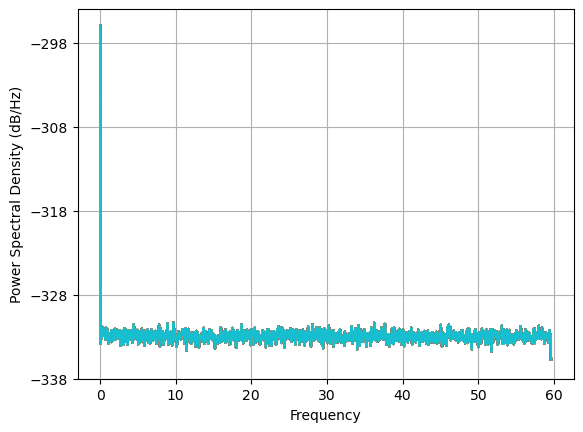

In [110]:
#nn = 172525
AI = 1
Ntemplates = 100
Span = 100
SNR_arr = np.zeros((16,Ntemplates, Span))
T_arr = []
for channel in range(2,3):
    dataI = f['AI ' + str(AI) + '/CH ' + str(channel+1) + '-I/Data'][:]*9.86e-10
    dataQ = f['AI ' + str(AI) + '/CH ' + str(channel+1) + '-Q/Data'][:]*9.86e-10
    NFFT = 2**12 # for NFFT < Nsample power spectrum will be averaged
    fn, SdataI = welch(dataI, fs=Fs, nperseg = 2*NFFT-1, scaling = 'density')
    fn, SdataQ = welch(dataQ, fs=Fs, nperseg = 2*NFFT-1, scaling = 'density')
    Q1,Q2, Gamma1, Gamma2,fc1,fc2 = fit_spectrum(SdataI, SdataQ, fn, plotting=False)
    
    f_demod = f['AI ' + str(AI)].attrs['Demod freqs AI ' + str(AI)][channel] # demodulation frequency
    tau1, tau2 = np.array([Q1,Q2])/(np.pi*f_demod)
    fpeak_sig = fc1
    Rdat = np.sqrt(dataI**2+dataQ**2)
    G = squid_model[AI][0]/np.sqrt(1+(f_demod/squid_model[AI][1])**2) #squid gain
    VtoT = (1/G)**2*resistances[channel][AI]*tau1/kb/4
    kappa = np.sqrt(f_demod*2*np.pi*meff[channel]/(Q1*resistances[channel][AI]))
    h = np.fft.ifft(np.fft.fft(Rdat[1:]/G)/(kappa*f_demod*2*np.pi)).real
    tau_vec = tau1*np.logspace(-1,1,Ntemplates)
    for i in range(Ntemplates):
        template = np.exp(-t_sig/(tau_vec[i]))
        SNR, dat_filt = optimal_filter(h, template, Fs, NFFT)
        SNR_arr[channel,i,:] = SNR[nn-Span//2:nn+Span//2]


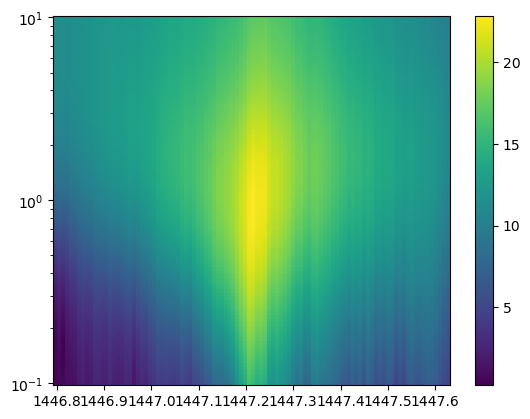

In [111]:
XX, YY = np.meshgrid(tn[nn-Span//2:nn+Span//2], tau_vec/tau1)
ZZ = SNR_arr[2,:,:]
plt.pcolormesh(XX,YY, ZZ, cmap='viridis')
plt.yscale('log')
plt.colorbar()
plt.show() 

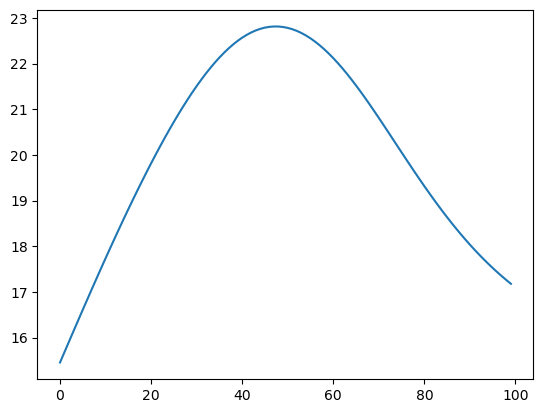

In [112]:
plt.plot(SNR_arr[2,:,Span//2])

We can now look at the full spectrum of triggers captured by this template matching selection process

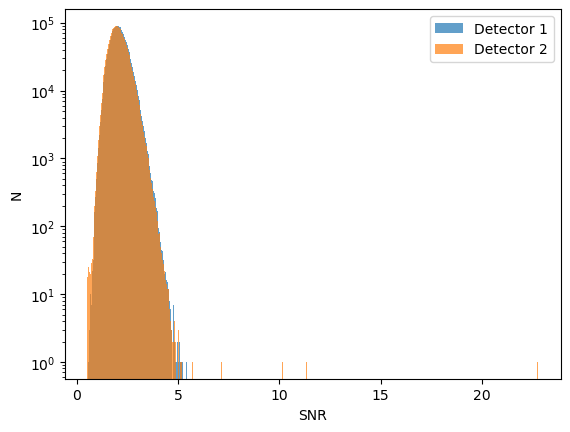

In [113]:
xmin = np.array([(np.array(SNRs0))[:,0].min(),(np.array(SNRs1))[:,0].min()]).min()
xmax = np.array([(np.array(SNRs0))[:,0].max(),(np.array(SNRs1))[:,0].max()]).max()

plt.hist((np.array(SNRs0))[:,0], alpha = 0.7, label = 'Detector 1', bins = 500, range = (xmin, xmax))
plt.hist((np.array(SNRs1))[:,0], alpha = 0.7, label = 'Detector 2', bins = 500, range = (xmin, xmax))
plt.yscale('log')
plt.xlabel('SNR')
plt.ylabel('N')
plt.legend(loc=0)
plt.show()

We see the spectrum for each channel look similar, with the addition of some high energy events, mostly in detector 2

This distribution is essentially sampled from the larger entire SNR distribution. As a result it displays a peak of mean ~ 2, however this is an artifact from the trigger selection process.

We show below that sampling the larger distribution of all SNR samples with a peak finding algorithim results in a mean-shifted sample distribution.

In [114]:
SNR_noise = np.random.normal(np.mean(SNR), np.std(SNR), size=len(SNR))

In [115]:
from scipy.stats import chi2
from scipy.stats import ncx2
from scipy.stats import norm

As we sample phase and quadreature data, we look at the distribution of the magnitude samples which should follow a chi-squared distribution as the quadratic sum of two gaussian processes

In [116]:
noise = chi2.rvs(2, loc=1.0, scale=1.0, size=len(SNR))

In [117]:
sampled_noise = find_peaks(noise, height = 1.0, distance = int(tau1*Fs), width = [None, None], rel_height=1.0)
sampled_peaks = sampled_noise[1]['peak_heights']
len(sampled_peaks)

7383

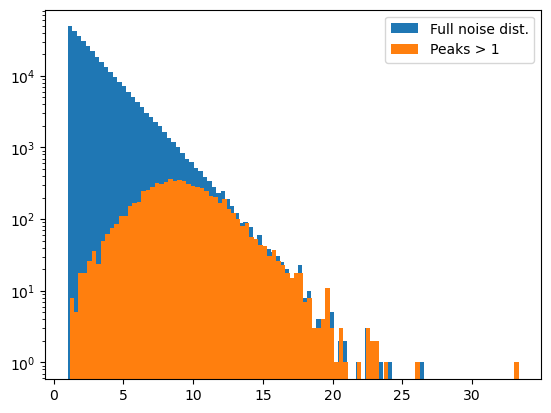

In [118]:
heights, bins, bars = plt.hist(noise, bins=100, density=False, label='Full noise dist.')
heights, bins, bars = plt.hist(sampled_peaks, bins=100, density=False, label='Peaks > 1')
plt.legend()
plt.yscale('log')

Thus taking a closer look at the tail of the trigger distribution for the real data, and recalling that our SNR matched filtering statistic is an amplitude SNR ratio such that Energy $\propto$ SNR^2:

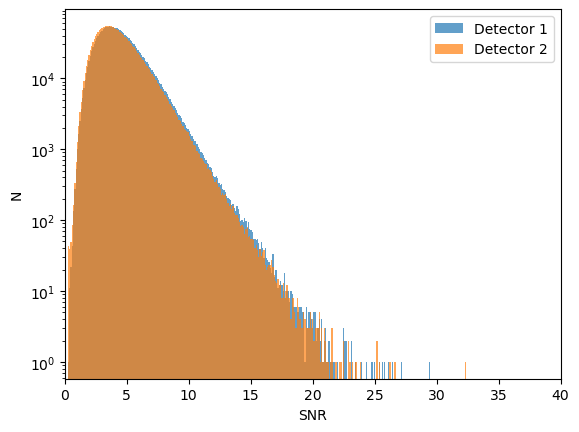

In [119]:
xmin = np.array([(np.array(SNRs0)**2)[:,0].min(),(np.array(SNRs1)**2)[:,0].min()]).min()
xmax = np.array([(np.array(SNRs0)**2)[:,0].max(),(np.array(SNRs1)**2)[:,0].max()]).max()
plt.hist((np.array(SNRs0)**2)[:,0], alpha = 0.7, label = 'Detector 1', bins = 5000, range = (xmin, xmax))
plt.hist((np.array(SNRs1)**2)[:,0], alpha = 0.7, label = 'Detector 2', bins = 5000, range = (xmin, xmax))
plt.yscale('log')
plt.xlabel('SNR')
plt.ylabel('N')
plt.legend(loc=0)
plt.xlim(0,40)
plt.show()

We see that the tail still follows an exponetial / chi squared dsitribution set by the effective temperature

The mean value of the sampled distribution is largley determined by the standard deviation of the original sample space. Would be proportional to the Ambient temperature of the detector

The analysis script saves any triggers that appear coincidnent in the two channels, from this we can take the largest trigger event as a threshold and determine the maximum distance from which we can exclude PBH mergers.

We will need to load the measured quality factors of the detector modes $Q_\lambda$, and the analytically calculated effective masses $m_\lambda$ and gravitional coupling factors $\xi_\lambda$

In [120]:
feffective_mass = open(r'C:\Users\21958742\MAGE\MAGE3/' + 'calibration/Meff.txt')
mode_distributions = np.genfromtxt(feffective_mass, delimiter=',', skip_header=1)
meff = mode_distributions[:,1]
xi = mode_distributions[:,2]

Q0 = [18058011.18, 1254696.59, 3494654.17,16962105.92, 5689899.46, 60565757.57, 33267926.78, 44653062.80, 30585969.48, 26510994.90
    , 37422944.61, 76843447.08, 93176978.34, 65648054.33, 115047095.19, 75204332.18]
Q1 = [48270564.00,630770.50,6453914.00,56212596.00,6115535.00,66870760.00,79754832.00,44126040.00,63588400.00,18052478.00,52137668.00,29066436.00,119769688.00,99094616.00,163072160.00,23392774.00]

We will determine the maximum SNR trigger event detected to be coincident in both detectors at the same time for each frequency, and convert this SNR back into a resonator amplitude, and then into a GW strain. From this excluded strain we determine a PBH merger distance from the equations given in the HFGW whitepaper.

In [121]:
Texcl = np.zeros(16)
hcexcl = np.zeros(16)
fvec = np.zeros(16)
Dexcl = np.zeros(16)
for i in range(16):
    channel=i
    Rt0 = np.max([event[0][1]['SNR'] for event in co_events if (event[0][1]['channel']==channel+1)])
    Rt1 = np.max([event[1][1]['SNR'] for event in co_events if (event[0][1]['channel']==channel+1)])

    Rtcombined = np.max([(event[0][1]['SNR']+event[1][1]['SNR']) for event in co_events if (event[0][1]['channel']==channel+1)])
    target_event0 = [event for event in co_events if event[0][1]['SNR'] == Rt0]
    target_event1 = [event for event in co_events if event[1][1]['SNR'] == Rt1]

    deth0 = target_event0[0][0][1]['amplitude']
    deth1 = target_event1[0][1][1]['amplitude']

    norm0 = 3.5/target_event0[0][0][1]['Teff']
    norm1 = 3.5/target_event0[0][1][1]['Teff']

    f_demod = target_event0[0][0][1]['frequency']

    normed_deth0, normed_deth1 = np.sqrt(norm0)*np.abs(deth0),  np.sqrt(norm1)*np.abs(deth1)

    T0,T1 = 0.5*np.abs(normed_deth0)**2*(f_demod*2*np.pi)**2*meff[channel]/(1.380649e-23), 0.5*np.abs(normed_deth1)**2*(f_demod*2*np.pi)**2*meff[channel]/(1.380649e-23)
    Texcl[i] = np.array([T0,T1]).max()
    fvec[i] = f_demod
    
    hcdet0 = np.abs(deth0)*np.sqrt(f_demod**2/2)/(0.5*1.093e-3*xi[channel]*Q0[channel])
    hcdet1 = np.abs(deth1)*np.sqrt(f_demod**2/2)/(0.5*1.093e-3*xi[channel]*Q1[channel])
    Mpbh = 4.3758e33/f_demod
    Msolar = 1.989e30
    MM = (Mpbh**2)**(3/5)/(2**(1/5)*Mpbh**(1/5))
    Ncycles = 5.42532e56/(f_demod**(3/2)*MM**(5/3))
    hc0, hc1 = hcdet0/np.sqrt(2*Ncycles), hcdet1/np.sqrt(2*Ncycles)
    hcexcl[i] = np.array([hc0,hc1]).max()
    D = 5.83209e-51*f_demod**(2/3)*MM**(5/3)/np.array([hc0,hc1]).max()
    Dexcl[i] = D

Text(0, 0.5, 'Distance (AU)')

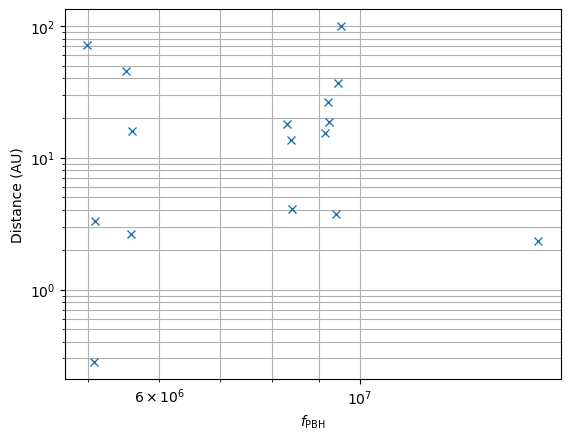

In [123]:
plt.plot(fvec, Dexcl/1.496E+11, linestyle = ' ', marker='x')
plt.xscale('log')
plt.yscale('log')
plt.grid(which='both')
plt.xlabel(r'$f_\mathrm{PBH}$')
plt.ylabel('Distance (AU)')

We see we can exclude PBH mergers to distances on the scale of the size of our solar system. To my knowledge previous best estimate was the Holometer which excluded mergers over ~ a few MHz of bandwidth between the earth and the moon. A far cry away from a real detection event but orders of magnitude improvement

Further analysis can be done to set broadband exclusion limits based on ring up phase and not just maximum amplitude at ISCO